# Self‑Adapting Evolution Strategy (ES)

In a self‑adapting ES the mutation step‑sizes (`F`) evolve together with the
solution. The library provides:
- `SelfAdaptingESEncoding` – appends `F` to each genotype (now fixed to use `"F"`).
- `ExtendedInitializer` – initialises solutions and `F` together.
- `AdaptativeOperator` – updates the mutation `F` with current values from the genotype.

We'll optimize the 3‑D **Sphere**, track the evolved `F`, and visualise both.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere
from metaheuristic_designer.encodings import SelfAdaptingESEncoding
from metaheuristic_designer.initializers import (
    UniformInitializer,
    ExtendedInitializer,
)
from metaheuristic_designer.operators import AdaptativeOperator
from metaheuristic_designer.survivor_selection_methods import (
    create_survivor_selection,
)

rng = mhd.check_random_state(42)

## 1. Objective function – Sphere in 2D

In [2]:
DIM = 3
objfunc = Sphere(DIM, mode="min")

## 2. Encoding: append `F` to each individual
`single_sigma=False` gives one `F` per dimension. The genotype is `[x1, x2, F1, F2]`.

In [3]:
encoding = SelfAdaptingESEncoding(vecsize=DIM, single_sigma=False)

## 3. Initializer – solutions and F
Solutions are uniformly drawn in [-10,10]; F values in [1e-3, 2].


In [4]:
solution_init = UniformInitializer(DIM, -10, 10, pop_size=30, random_state=rng)
F_init        = UniformInitializer(DIM, 1e-3, 2, pop_size=30, random_state=rng)

initializer = ExtendedInitializer(
    solution_init=solution_init,
    param_init_dict={"F": F_init},   # key must match encoding parameter name
    encoding=encoding,
)

## 4. Operators – mutate solution & F

- **Solution mutation**: Gaussian mutation with one component, its `F` will be updated by the adaptative operator.
- **F mutation**: self‑adaptation via log‑normal update (`mutate_n_sigmas` on the F part).
- **AdaptativeOperator** decodes the current `F` from the genotype and passes it to the solution mutation.

In [5]:
solution_mut = mhd.operators.create_operator(
    "mutation.gaussian_mutation",
    N=1,
    F=1.0,       # initial placeholder, will be overwritten each generation
    random_state=rng,
)

F_mut = mhd.operators.create_operator(
    "mutate_n_sigmas",
    epsilon=1e-3,
    tau=0.1,
    tau_multiple=0.2,
    random_state=rng,
)

operator = AdaptativeOperator(
    base_operator=solution_mut,
    param_operators={"F": F_mut},   # key matches encoding & initializer
    encoding=encoding,
)

## 5. Survivor selection – (μ+λ)

In [6]:
survivor_sel = create_survivor_selection("(mu+lambda)", random_state=rng)

## 6. Build strategy and algorithm

In [7]:
strategy = mhd.SearchStrategy(
    initializer=initializer,
    operator=operator,
    survivor_sel=survivor_sel,
    random_state=rng,
)

algo = mhd.algorithms.StandardAlgorithm(
    objfunc, strategy,
    ngen=100, stop_cond="ngen", verbose=True,
)

## 7. Run and track F evolution
We manually step, decode the `F` values from the population, and record their mean.

In [8]:
F_history, fit_history = [], []
algo.initialize()

for gen in range(100):
    algo.step()
    algo.update()
    # Extract current F from genotype
    current_geno = algo.search_strategy.population.genotype_matrix
    params = encoding.decode_params(current_geno)
    F_vals = params["F"]
    F_history.append(F_vals.mean(axis=0))   # store mean per dimension
    _, best_fit = algo.best_solution()
    fit_history.append(best_fit)

F_history = np.array(F_history)

## 8. Visualise fitness and F

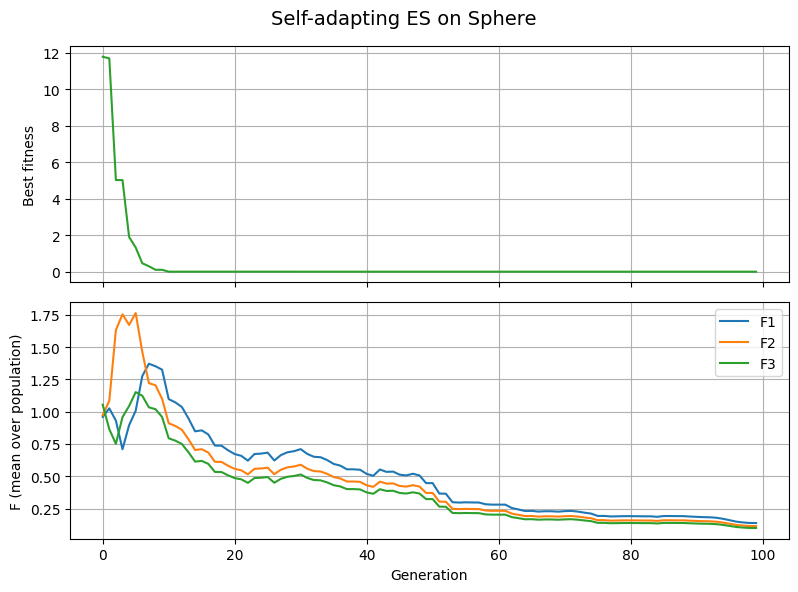

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,6))

ax1.plot(fit_history, color="tab:green")
ax1.set_ylabel("Best fitness")
ax1.grid(True)

for d in range(DIM):
    ax2.plot(F_history[:, d], label=f"F{d+1}")
ax2.set_xlabel("Generation")
ax2.set_ylabel("F (mean over population)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Self-adapting ES on Sphere", fontsize=14)
plt.tight_layout()
plt.show()